# Análise Exploratória e Tratamento de Dados

Os bancos desempenham um papel crucial nas economias de mercado. Ao decidirem quem recebe financiamento e em que termos e podem tomar ou quebrar decisões de investimento. Para que a grande roda da economia funcione, os indivíduos e empresas precisam de acesso ao crédito.

Dentre os critérios para aprovação de crédito, algoritmos de pontuação de crédito, que fazem um palpite sobre a probabilidade de inadimplência, são um dos métodos que os bancos usam para determinar se um empréstimo deve ou não ser concedido. Nesse contexto, selecionamos como dataset desse trabalho o [GiveSomeCredit](https://www.kaggle.com/competitions/GiveMeSomeCredit/), que originalmente fazia parte de uma competição do Kaggle, exigia que os participantes prevessem a probabilidade de que alguém fique inadimplente nos próximos dois anos. Os dados do dataframe são reais e são fornecidos sobre 250.000 mutuários, sendo divididos em 150.000 para treino e 100.000 para teste, aproximadamente.

### Instalando as bibliotecas

Inicialmente, vamos importar as bibliotecas que iremos usar:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyampute.exploration.mcar_statistical_tests import MCARTest

Agora, vamos carregar os dataframes e verificar o seu tamanho:

In [5]:
dictionary = pd.read_csv("original_data/Data Dictionary.csv", index_col=0) # dicionario das features
df_train_raw = pd.read_csv("original_data/cs-training.csv", index_col=0) # dataframe de treino sem o índice
df_test_raw  = pd.read_csv("original_data/cs-test.csv",  index_col=0) # dataframe de teste sem o índice
probability = pd.read_csv("original_data/sampleEntry.csv", index_col=0) # probabilidades do teste

print("TRAIN shape:", df_train_raw.shape)
print("TEST  shape:", df_test_raw.shape)
print("PROB  shape:", probability.shape)

TRAIN shape: (150000, 11)
TEST  shape: (101503, 11)
PROB  shape: (101503, 1)


Com os dados em mão, vamos observar algum padrão ou algo que possa atrapalhar a análise:

In [6]:
dictionary

,Description,Type
Variable Name,,
SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
age,Age of borrower in years,integer
NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
MonthlyIncome,Monthly income,real
NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


In [7]:
df_train_raw.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [8]:
df_test_raw.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


In [9]:
probability.describe()

,Probability
count,101503.000000
mean,0.067664
std,0.110445
min,0.003513
25%,0.011705
50%,0.023285
75%,0.067193
max,0.826056


In [10]:
df_train_raw.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [11]:
df_test_raw.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0
6,NaN,0.509791,63,0,0.342429,4140.0,4,0,0,0,1.0
7,NaN,0.587778,50,0,1048.000000,0.0,5,0,0,0,3.0
8,NaN,0.046149,79,1,0.369170,3301.0,8,0,1,0,1.0
9,NaN,0.013527,68,0,2024.000000,NaN,4,0,1,0,0.0
10,NaN,1.000000,23,98,0.000000,0.0,0,98,0,98,0.0


In [12]:
probability.head(10)

,Probability
Id,
1,0.080807
2,0.040719
3,0.011968
4,0.067640
5,0.108264
6,0.027520
7,0.047294
8,0.041027
9,0.004223


Agora, vamos ver a correlação dos dados:

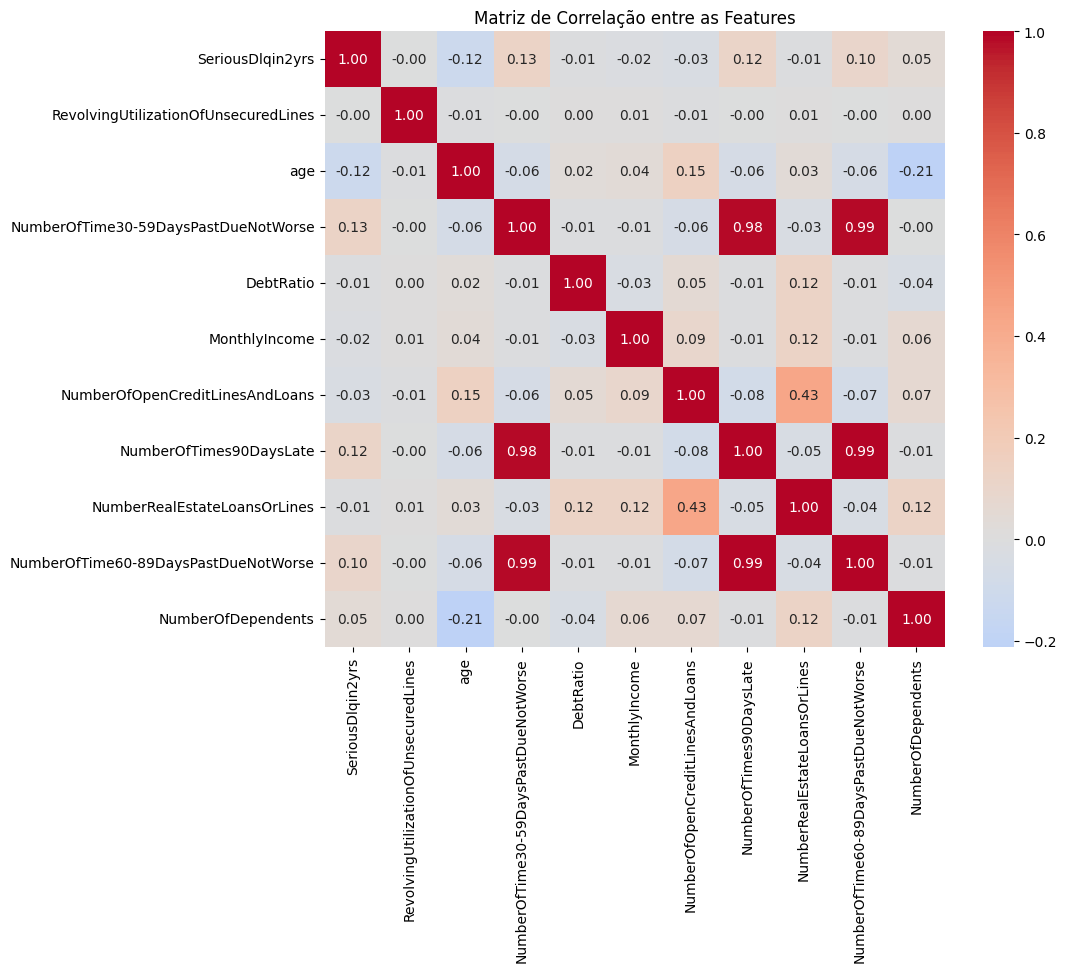

In [13]:
numeric_cols = df_train_raw.select_dtypes(include=["int64", "float64"])
corr = numeric_cols.corr()

# mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação entre as Features")
plt.show()

Com a nossa matriz de correlação, percebemos alguma correlação (ou seja, linearidade entre os dados) entre as features:

`NumberOfTime30-59DaysPastDueNotWorse` & `NumberOfTime60-89DaysPastDueNotWorse` & `NumberOfTimes90DaysLate` ;

`NumberOfOpenCreditLinesAndLoans` & `NumberRealEstateLoansOrLines` ; 

`age` & `NumberOfDependents`

Em relação aos datasets, percebe-se que temos alguns dados faltando, assim, vamos vizualizar a matriz que mostra a distribuição dessas ausências, inicialmente com o de treino:

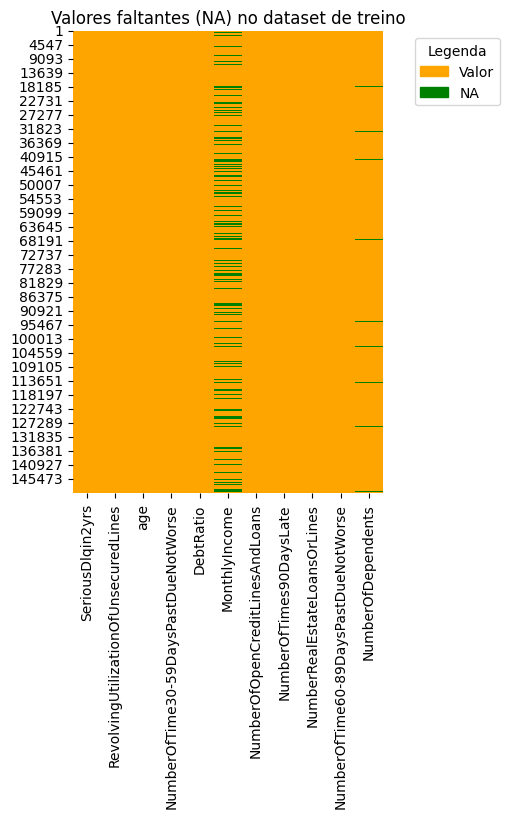

In [14]:
composite_train = df_train_raw.isna().astype(int)

colors = ['orange', 'green']  # 0 = Valor, 1 = NaN
custom_cmap = sns.color_palette(colors)

plt.figure(figsize=(4, 6))
sns.heatmap(composite_train, cbar=False, cmap=custom_cmap, vmax=1, vmin=0)
handles = [plt.Rectangle((0,0),1,1, color=custom_cmap[i]) for i in range(len(colors))]
plt.legend(handles, ["Valor", "NA"], title="Legenda", loc="upper right", bbox_to_anchor=(1.4, 1))
plt.title("Valores faltantes (NA) no dataset de treino")
plt.show()

Com o de teste:

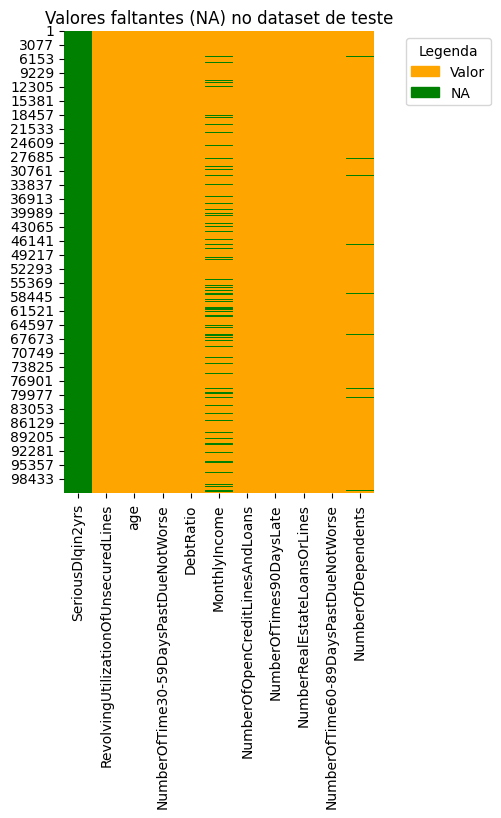

In [15]:
composite_test = df_test_raw.isna().astype(int)

colors = ['orange', 'green']  # 0 = Valor, 1 = NaN
custom_cmap = sns.color_palette(colors)

plt.figure(figsize=(4, 6))
sns.heatmap(composite_test, cbar=False, cmap=custom_cmap, vmax=1, vmin=0)
handles = [plt.Rectangle((0,0),1,1, color=custom_cmap[i]) for i in range(len(colors))]
plt.legend(handles, ["Valor", "NA"], title="Legenda", loc="upper right", bbox_to_anchor=(1.4, 1))
plt.title("Valores faltantes (NA) no dataset de teste")
plt.show()

Nessa análise inicial, observa-se que em ambos os datasets temos dados faltando nas features `MonthlyIncome` e `NumberOfDependents`. Além disso, percebe-se que no dataset de treino temos a feature `SeriousDlqin2yrs` sem dados. Isso acontece, porque essa feature era o que o problema original queria estimar(completar). Agora, vamos contar quantos são esse dados faltantes:

In [16]:
na_count = pd.DataFrame({
    "Dataset de Treino": df_train_raw.isna().sum(), # conta cada dado faltante em cada feature no dataset de treino
    "Dataset de Teste": df_test_raw.isna().sum()  # conta cada dado faltante em cada feature no dataset de teste
})

na_count

,Dataset de Treino,Dataset de Teste
SeriousDlqin2yrs,0,101503
RevolvingUtilizationOfUnsecuredLines,0,0
age,0,0
NumberOfTime30-59DaysPastDueNotWorse,0,0
DebtRatio,0,0
MonthlyIncome,29731,20103
NumberOfOpenCreditLinesAndLoans,0,0
NumberOfTimes90DaysLate,0,0
NumberRealEstateLoansOrLines,0,0
NumberOfTime60-89DaysPastDueNotWorse,0,0


Para facilitar a o tratamento, vamos fazer a imputação das probabilidades no dataset de treino. Para isso, vamos analisar as probabilidades:

In [17]:
probability.describe()

,Probability
count,101503.000000
mean,0.067664
std,0.110445
min,0.003513
25%,0.011705
50%,0.023285
75%,0.067193
max,0.826056


Veja que não temos nenhum valor 0 ou 1, o que diferencia os dados de treino e teste. Nesse caso, podemos fazer a concatenar os datasets em um único só. Agora, vamos imputar as probabilidades:

In [18]:
df_test_raw = df_test_raw.drop(columns=['SeriousDlqin2yrs'])

df_test_raw['SeriousDlqin2yrs'] = probability['Probability']

df_test_raw.head(10)

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
1,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0.080807
2,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0.040719
3,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0.011968
4,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,0.067640
5,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0.108264
6,0.509791,63,0,0.342429,4140.0,4,0,0,0,1.0,0.027520
7,0.587778,50,0,1048.000000,0.0,5,0,0,0,3.0,0.047294
8,0.046149,79,1,0.369170,3301.0,8,0,1,0,1.0,0.041027
9,0.013527,68,0,2024.000000,NaN,4,0,1,0,0.0,0.004223
10,1.000000,23,98,0.000000,0.0,0,98,0,98,0.0,0.377129


E vamos criar o dataset completo:

In [19]:
df_all = pd.concat(
    [df_train_raw, df_test_raw],
    axis=0,
    ignore_index=True
)

print(df_all.shape)

(251503, 11)


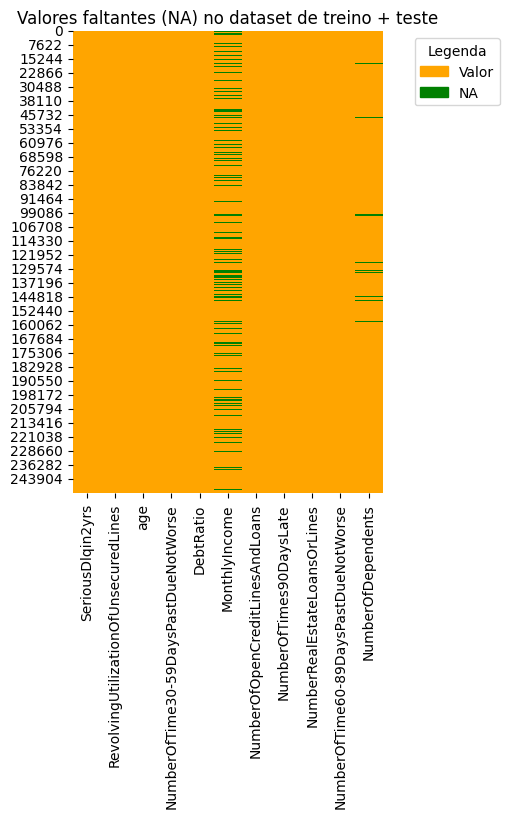

In [20]:
# vamos visualizar os dados faltantes no dataset completo

composite_all = df_all.isna().astype(int)

colors = ['orange', 'green']  # 0 = Valor, 1 = NaN
custom_cmap = sns.color_palette(colors)

plt.figure(figsize=(4, 6))
sns.heatmap(composite_all, cbar=False, cmap=custom_cmap, vmax=1, vmin=0)
handles = [plt.Rectangle((0,0),1,1, color=custom_cmap[i]) for i in range(len(colors))]
plt.legend(handles, ["Valor", "NA"], title="Legenda", loc="upper right", bbox_to_anchor=(1.4, 1))
plt.title("Valores faltantes (NA) no dataset de treino + teste")
plt.show()

Como a quantidade de dados faltantes da feature `NumberOfDependents` é pequena (cerca de 6.000 dados de 250.000), então vamos remover os dados com números de dependentes ausentes:

In [21]:
df_all.dropna(subset=['NumberOfDependents'], inplace=True)

Agora, o que podemos fazer com os dados faltantes da feature `MonthlyIncome`?

Será que vale a pena excluir esses dados?

Inicialmente, por praticidade, poderiamos remover esses dados, já que totalizam em média 20% de todo o dataset. Nesse caso, ainda restariam 80% dos dados em que poderiamos trabalhar, o que não tem muita relevância.

Mas, e se esses dados ausentes tiverem um certo viés? Será que ao remover esses dados, estariamos perdendo esse viés que deve ser agregado no modelo?

Como forma de responder essas perguntas, vamos aplicar o teste de hipótese de MCAR (*Missing Completely At Random*) :

| Valor de p       | Interpretação                                                                   |
| ----------------- | -------------------------------------------------------------------------------------------------- |
| pv < 0.05      | Rejeitamos $H_0$, logo os dados não são MCAR, então os dados faltantes dependem de outras features |
| pv ≥ 0.05      | Não rejeitamos $H_0$, logo os dados podem ser considerados MCAR, ou seja, eles faltam de forma aleatória            |


In [22]:
mcar_tester = MCARTest(method='little')

pv = mcar_tester.little_mcar_test(df_all)

pv

np.float64(0.0)

Com isso rejeitamos $H_0$, então os dados ausentes não são completamente aleatórios, ou seja, dependem de alguma forma das outras features do dataset. Desse modo, não podemos apenas remover os dados ausentes. Nesse contexto, vamos analisar melhor a distribuição da renda:

In [23]:
renda_sem_nan = df_all['MonthlyIncome'].dropna()

quartis = renda_sem_nan.quantile([0.25, 0.5, 0.75, 0.9, 0.99, 0.9999])
print(quartis)

print(renda_sem_nan.skew())
print(renda_sem_nan.max())
print(renda_sem_nan.min())

0.2500      3400.00
0.5000      5400.00
0.7500      8212.00
0.9000     11600.00
0.9900     25050.36
0.9999    438040.10
Name: MonthlyIncome, dtype: float64
195.75627387813307
7727000.0
0.0


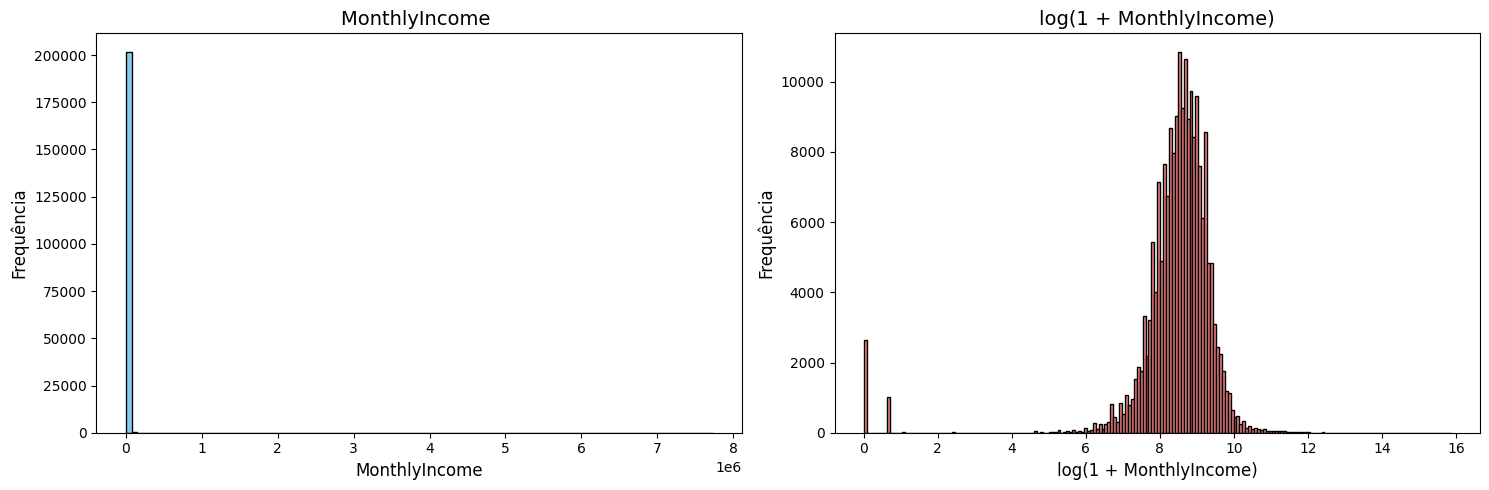

In [24]:
# visualização da distribuição da renda

renda_original = df_all['MonthlyIncome'].dropna()

renda_log = np.log1p(renda_original)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(renda_original, bins=100, color='skyblue', edgecolor='black')
axes[0].set_title('MonthlyIncome ', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

axes[1].hist(renda_log, bins=200, color='lightcoral', edgecolor='black')
axes[1].set_title('log(1 + MonthlyIncome)', fontsize=14)
axes[1].set_xlabel('log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

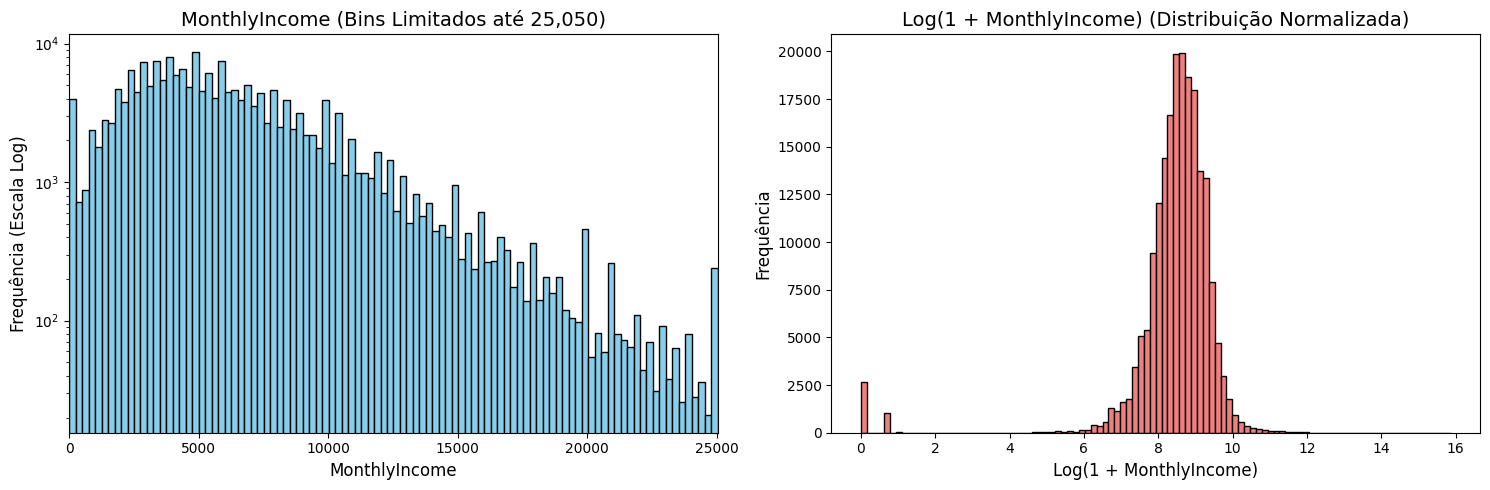

O limite de corte usado para criar os bins foi o 99º percentil: R$ 25,050.36


In [25]:
# visualização da distribuição da renda utilizando escala logarítmica no eixo Y

renda_original = df_all['MonthlyIncome'].dropna()
renda_log = np.log1p(renda_original)

# vamos usar o 99º percentil para incluir 99% dos dados
limite_para_bins = renda_original.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# usamos 'range=(0, limite_para_bins)' para que os 100 bins sejam criados de forma uniforme apenas dentro desta faixa de 0 a limite_para_bins.
axes[0].hist(
    renda_original,
    bins=100,
    range=(0, limite_para_bins),
    color='skyblue',
    edgecolor='black'
)

axes[0].set_title(f'MonthlyIncome (Bins Limitados até {limite_para_bins:,.0f})', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência (Escala Log)', fontsize=12)

# mantem a escala logarítmica no eixo Y ajuda a ver a diferença entre as barras
axes[0].set_yscale('log')

axes[0].set_xlim(0, limite_para_bins)

axes[1].hist(renda_log, bins=100, color='lightcoral', edgecolor='black')
axes[1].set_title('Log(1 + MonthlyIncome) (Distribuição Normalizada)', fontsize=14)
axes[1].set_xlabel('Log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

print(f"O limite de corte usado para criar os bins foi o 99º percentil: R$ {limite_para_bins:,.2f}")

Essa distribuição dos dados de renda sugere que os dados segue alguma distribuição. Por isso, vamos aplicar o Teste de Kolmogorov–Smirnov, que verifica qual distribuição se ajusta melhor à variável resposta Y. Nesse caso, temos como cadidatos a distribuição Gamma e a distribuição Log-Normal. Nesse teste, a hipótese nula é que os dados seguem a distribuição.

In [26]:
from scipy.stats import lognorm, gamma, kstest

renda_original = renda_original + 1

params_lognorm = lognorm.fit(renda_original)
s_ln, loc_ln, scale_ln = params_lognorm


params_gamma = gamma.fit(renda_original)
a_g, loc_g, scale_g = params_gamma


ks_stat_ln, p_value_ln = kstest(renda_original, 'lognorm', args=params_lognorm)

ks_stat_g, p_value_g = kstest(renda_original, 'gamma', args=params_gamma)

print("\n LOG-NORMAL")
print(f"KS Statistic (D): {ks_stat_ln:.4f}")
print(f"P-valor", p_value_ln)


print("\n GAMMA")
print(f"KS Statistic (D): {ks_stat_g:.4f}")
print(f"P-valor", p_value_g)




 LOG-NORMAL
KS Statistic (D): 0.0283
P-valor 1.3272385460014042e-140

 GAMMA
KS Statistic (D): 1.0000
P-valor 0.0


Veja que P-valor de Gamma é $\le0,05$, então rejeitamos $H_0$, logo a distribuição Gamma não representa bem a distribuiçõ dos dados. Como não rejeitamos $H_0$ da distribuição Log-Normal, então usaremos ela para treinar o modelo. Agora, vamos analisar o dataset como um todo:

In [27]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244953 entries, 0 to 251502
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      244953 non-null  float64
 1   RevolvingUtilizationOfUnsecuredLines  244953 non-null  float64
 2   age                                   244953 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  244953 non-null  int64  
 4   DebtRatio                             244953 non-null  float64
 5   MonthlyIncome                         201669 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       244953 non-null  int64  
 7   NumberOfTimes90DaysLate               244953 non-null  int64  
 8   NumberRealEstateLoansOrLines          244953 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  244953 non-null  int64  
 10  NumberOfDependents                    244953 non-null  float64
dtypes: fl

In [28]:
df_all.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000,2.016690e+05,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000
mean,0.067677,5.689943,52.145877,0.420628,331.537394,6.744818e+03,8.529036,0.262512,1.028242,0.236674,0.761995
std,0.205988,230.310730,14.605595,4.146371,1825.891030,2.571761e+04,5.146429,4.121278,1.125249,4.107044,1.123905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031093,41.000000,0.000000,0.171311,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.158062,52.000000,0.000000,0.356968,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.022149,0.565351,62.000000,0.000000,0.761885,8.212000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,107.000000,98.000000,329664.000000,7.727000e+06,85.000000,98.000000,54.000000,98.000000,43.000000


Nosso plano é treinar uma GAM(Generalized Additive Models) para fazer a imputação dos dados seguindo a distribuição Log-Normal:

- Estratégia de imputação:
  - Link (g): Identidade  
  - Distribuição: Log(Y) ~ Normal  

Essa abordagem implica que estamos modelando a variável resposta transformada em logaritmo como uma variável normalmente distribuída, mantendo uma relação linear direta via função de ligação identidade.

Hipóteses do Modelo

1. A variável resposta $Y$ é explicada por um conjunto de covariáveis $X$.

2. O conjunto paramétrico de distribuições pertence à família exponencial, apropriada para $Y$.

3. A função de ligação $g$ conecta a esperança de $Y$ à soma das funções $f_i$, de modo que a média da resposta transformada por $g$ é aditiva nos efeitos das variáveis $x_i$:

$$g(\mathbb{E}[Y]) = \beta_0+f_1(x_1)+\cdots+f_n(x_n)$$

4. Não há interação entre as variáveis os efeitos são considerados independentes.

5. As observações são independentes entre si.

Como estamos utilizando splines, assumimos que as funções $f_i$ são suaves, ou seja, apresentam variação contínua e controlada ao longo do domínio das variáveis explicativas.

In [29]:
from pygam import LinearGAM, s
from sklearn.model_selection import GridSearchCV, KFold

df = df_all.copy()

# adicionar as interações entre as features

df['age_x_dependents'] = df['age'] * df['NumberOfDependents']

df['realestate_x_opencredit'] = df['NumberRealEstateLoansOrLines'] * df['NumberOfOpenCreditLinesAndLoans']

df['late_combined'] = (
    df['NumberOfTimes90DaysLate'] *
    df['NumberOfTime60-89DaysPastDueNotWorse'] *
    df['NumberOfTime30-59DaysPastDueNotWorse']
)


mask_complete = df['MonthlyIncome'].notnull()
mask_missing = df['MonthlyIncome'].isnull()

cols_to_use = [c for c in df.columns if c not in ['MonthlyIncome', 'SeriousDlqin2yrs', 'DebtRatio',]]

In [30]:
eps = 1e-6
X = df.loc[mask_complete, cols_to_use]
y = np.log(df.loc[mask_complete, 'MonthlyIncome']+eps)

terms = s(0)
for i in range(1, X.shape[1]):
    terms += s(i)

In [31]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lams = [0.01,0.05, 0.1, 1, 10]
splines = [10, 20, 30]

best_score = np.inf
best_model = None

for lam in lams:
    for ns in splines:

        scores = []

        for train_idx, test_idx in cv.split(X):
            gam = LinearGAM(terms, lam=lam, n_splines=ns).fit(
                X.values[train_idx],
                y.values[train_idx]
            )


            res = gam.deviance_residuals(
                X.values[test_idx],
                y.values[test_idx]
            )

            score = np.sum(res**2)

            scores.append(score)

        avg_score = np.mean(scores)
        print(f"lam={lam}, n_splines={ns}, score={avg_score:.3f}")

        if avg_score < best_score:
            best_score = avg_score
            best_model = gam

gam = best_model


lam=0.01, n_splines=10, score=288925.150
lam=0.01, n_splines=20, score=427227.415
lam=0.01, n_splines=30, score=498324.307
lam=0.05, n_splines=10, score=286619.065
lam=0.05, n_splines=20, score=310757.876
lam=0.05, n_splines=30, score=391380.657
lam=0.1, n_splines=10, score=286172.839
lam=0.1, n_splines=20, score=295284.923
lam=0.1, n_splines=30, score=344392.439
lam=1, n_splines=10, score=285130.113
lam=1, n_splines=20, score=285331.863
lam=1, n_splines=30, score=287523.280
lam=10, n_splines=10, score=284718.040
lam=10, n_splines=20, score=284695.385
lam=10, n_splines=30, score=284900.625


In [32]:
gam.fit(X.values, y.values)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + intercept,
   tol=0.0001, verbose=False)

In [33]:
X_missing = df.loc[mask_missing, cols_to_use]

y_pred = gam.predict(X_missing.values)

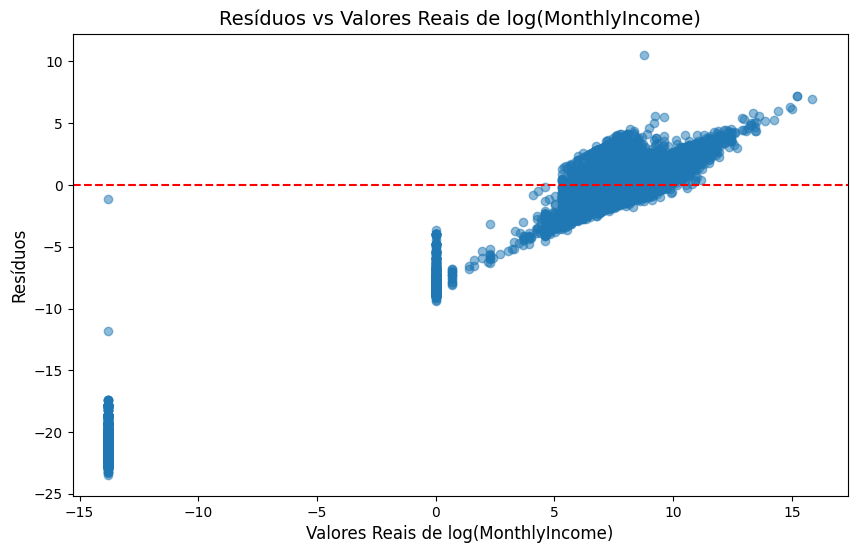

In [34]:
y_pred = np.exp(y_pred)

resid = y.values - gam.predict(X.values)
sigma = resid.std()

plt.figure(figsize=(10, 6))
plt.scatter(y.values, resid, alpha=0.5)
plt.title("Resíduos vs Valores Reais de log(MonthlyIncome)", fontsize=14)
plt.xlabel("Valores Reais de log(MonthlyIncome)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.axhline(0, color='red', linestyle='--')
plt.show()

Esse gráfico acima sugere que pode ter havido uma má especificação do modelo, mas adicionando termos de interação obtemos resultado similar.

In [35]:
# y_pred_stoc = np.maximum(np.exp(y_pred + np.random.normal(0, sigma, size=y_pred.shape)), 0)

df_imputed = df.copy()
df_imputed.loc[mask_missing, 'MonthlyIncome'] = y_pred

In [36]:
print(f"Valores imputados → min={y_pred.min():.2f}, max={y_pred.max():.2f}, média={y_pred.mean():.2f}")

assert (df_imputed['MonthlyIncome'] >= 0).all(), "Há valores negativos imputados!"

Valores imputados → min=37.57, max=24001.22, média=3670.97


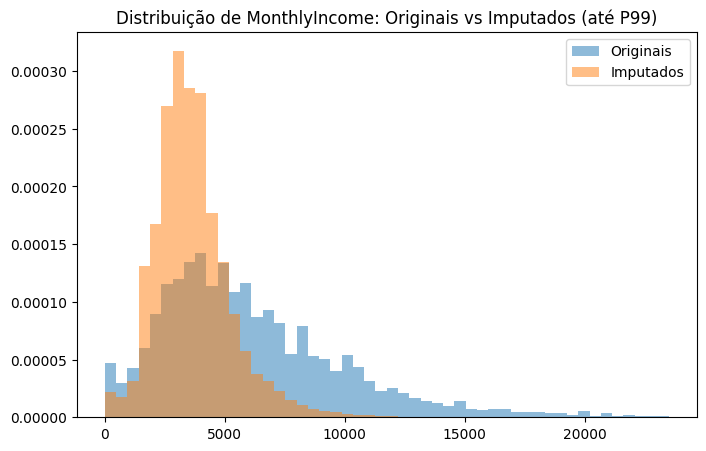

In [37]:
data_original = df.loc[mask_complete, 'MonthlyIncome'].dropna()
data_imputed = df_imputed.loc[mask_missing, 'MonthlyIncome'].dropna()

all_data = pd.concat([data_original, data_imputed])
upper_limit = np.percentile(all_data, 99)

plt.figure(figsize=(8,5))
plt.hist(data_original, bins=50, alpha=0.5, label='Originais', range=(0, upper_limit),  density =True,)
plt.hist(data_imputed, bins=50, alpha=0.5, label='Imputados', range=(0, upper_limit),  density =True,)
plt.legend()
plt.title("Distribuição de MonthlyIncome: Originais vs Imputados (até P99)")
plt.show()

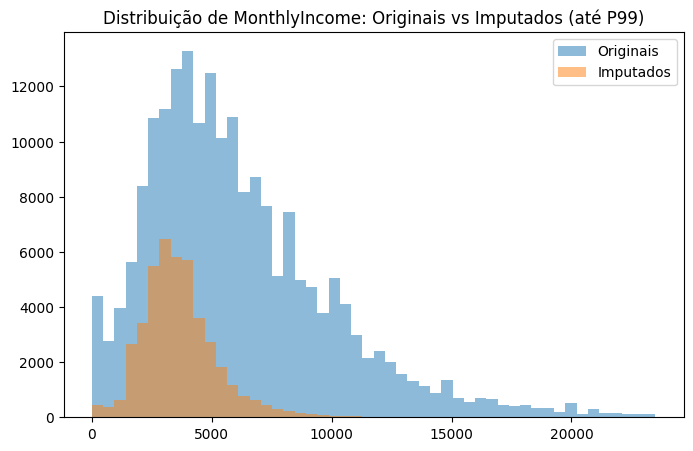

In [38]:
data_original = df.loc[mask_complete, 'MonthlyIncome'].dropna()
data_imputed = df_imputed.loc[mask_missing, 'MonthlyIncome'].dropna()

all_data = pd.concat([data_original, data_imputed])
upper_limit = np.percentile(all_data, 99)

plt.figure(figsize=(8,5))
plt.hist(data_original, bins=50, alpha=0.5, label='Originais', range=(0, upper_limit))
plt.hist(data_imputed, bins=50, alpha=0.5, label='Imputados', range=(0, upper_limit))
plt.legend()
plt.title("Distribuição de MonthlyIncome: Originais vs Imputados (até P99)")
plt.show()

In [39]:
new_cols = [
    'age_x_dependents',
    'realestate_x_opencredit',
    'late_combined'
]

df_imputed.drop(columns=new_cols, inplace=True)


In [40]:
# dividimos o dataset em dois: um com os dados originais (0 e 1 na variável alvo) e outro com os dados de teste (valores entre 0 e 1 na variável alvo)

df_tn = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] == 0) | (df_imputed['SeriousDlqin2yrs'] == 1)
].copy()


df_tt = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] != 0) & (df_imputed['SeriousDlqin2yrs'] != 1)
].copy()


df_tn.to_csv('df_tn.csv', index=False)

df_tt.to_csv('df_tt.csv', index=False)